In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
cruise_raw_data = pd.read_excel("lapse_data.xlsx", sheet_name="cruise").astype(float)
wet_raw_data = pd.read_excel("lapse_data.xlsx", sheet_name="wet").astype(float)
mil_raw_data = pd.read_excel("lapse_data.xlsx", sheet_name="military").astype(float)

print(cruise_raw_data.head())
print(wet_raw_data.head())
print(mil_raw_data.head())

   altitude (ft)  speed (kt)  rpm (%)  net thrust (lb)  net tsfc (hr-1)
0            0.0       200.0     90.0           2600.0            1.481
1            0.0       200.0     98.0           3740.0            1.390
2            0.0       200.0    100.0           4450.0            1.382
3            0.0       300.0     90.0              NaN              NaN
4            0.0       300.0     98.0           3450.0            1.522
   altitude (ft)  speed (kt)  net thrust (lb)  net tsfc (hr-1)
0            0.0       100.0           7240.0            2.444
1            0.0       200.0           7110.0            2.546
2            0.0       300.0           7280.0            2.542
3        15000.0       400.0           5540.0            2.867
4        15000.0       500.0           6090.0            2.689
   altitude (ft)  speed (kt)  net thrust (lb)  net tsfc (hr-1)
0            0.0       100.0           5100.0            1.275
1            0.0       200.0           4840.0            1.364
2

## Cruise

In [3]:
cruise_raw_data_mask = cruise_raw_data["rpm (%)"] == 98.0
cruise_raw_data_preselection = cruise_raw_data[cruise_raw_data_mask]
cruise_data = cruise_raw_data_preselection.groupby(
    "altitude (ft)", as_index=False
).mean()
cruise_data

,altitude (ft),speed (kt),rpm (%),net thrust (lb),net tsfc (hr-1)
0,0.0,300.0,98.0,3483.333333,1.522667
1,15000.0,500.0,98.0,2313.333333,1.626667
2,25000.0,500.0,98.0,1781.666667,1.557333
3,35000.0,500.0,98.0,1316.666667,1.471000
4,45000.0,500.0,98.0,850.000000,1.438000
5,50000.0,500.0,98.0,643.333333,1.521333


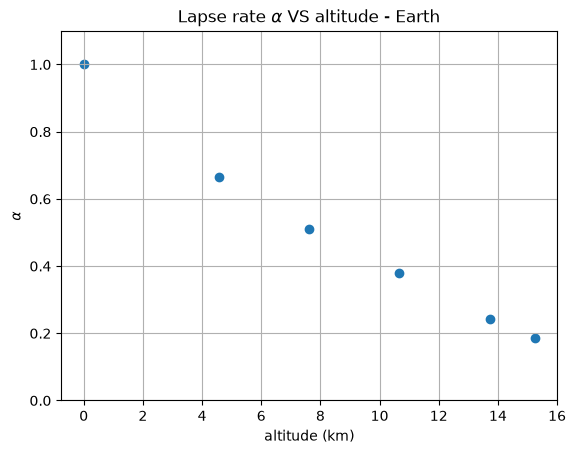

In [4]:
from airsize.units import ft2m

cruise_altitude_data = ft2m(cruise_data["altitude (ft)"])
cruise_lapse_rate_data = (
    cruise_data["net thrust (lb)"] / cruise_data["net thrust (lb)"].iloc[0]
)

plt.scatter(cruise_altitude_data / 1000, cruise_lapse_rate_data)
plt.grid()
plt.xlabel("altitude (km)")
plt.ylabel(r"$\alpha$")
plt.title(r"Lapse rate $\alpha$ VS altitude - Earth")
plt.ylim(0, 1.1)
plt.show()

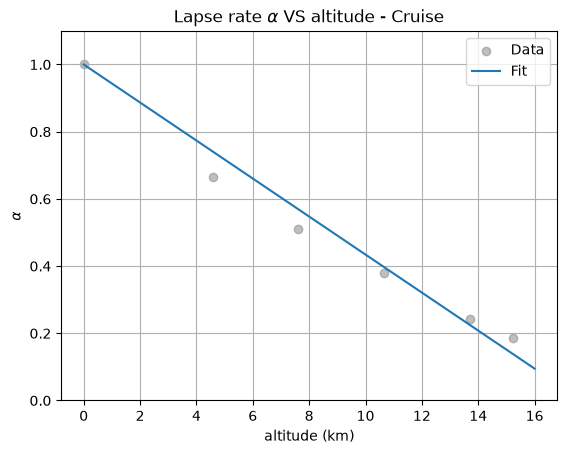

In [5]:
import numpy as np
from sklearn.linear_model import LinearRegression

cruise_alpha_model = LinearRegression(fit_intercept=False)
cruise_alpha_model.fit(
    cruise_altitude_data.values.reshape(-1, 1),
    cruise_lapse_rate_data.values.reshape(-1, 1) - 1,
)
altitude_predict = np.linspace(0.0, 16e3, 1000)
lapse_rate_predict = 1 + cruise_alpha_model.predict(altitude_predict.reshape(-1, 1))

plt.scatter(
    cruise_altitude_data / 1000,
    cruise_lapse_rate_data,
    label="Data",
    color="gray",
    alpha=0.5,
)
plt.plot(altitude_predict / 1000, lapse_rate_predict, label="Fit")
plt.grid()
plt.xlabel("altitude (km)")
plt.ylabel(r"$\alpha$")
plt.title(r"Lapse rate $\alpha$ VS altitude - Cruise")
plt.ylim(0, 1.1)
plt.legend()
plt.savefig("alpha_model_cruise.png")
plt.show()

In [6]:
print("slope for the cruise alpha model:", cruise_alpha_model.coef_.squeeze(), "m-1")

slope for the cruise alpha model: -5.6572725331908556e-05 m-1


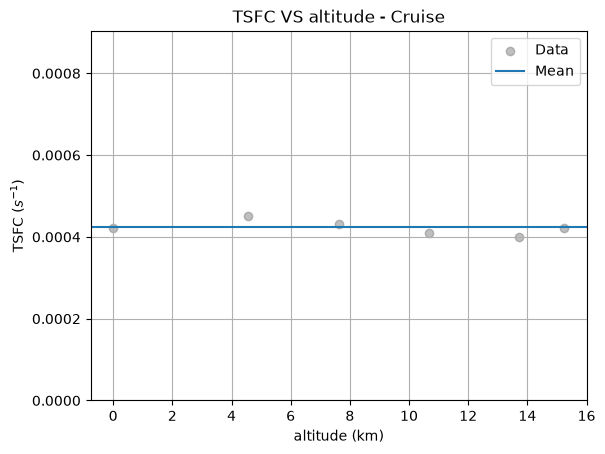

In [7]:
cruise_altitude_data = ft2m(cruise_data["altitude (ft)"])
cruise_tsfc_data = cruise_data["net tsfc (hr-1)"] / 3600
cruise_avg_tsfc = cruise_tsfc_data.mean()

plt.scatter(
    cruise_altitude_data / 1000, cruise_tsfc_data, color="gray", alpha=0.5, label="Data"
)
plt.axhline(cruise_avg_tsfc, label="Mean")
plt.grid()
plt.xlabel("altitude (km)")
plt.ylabel(r"TSFC ($s^{-1}$)")
plt.title(r"TSFC VS altitude - Cruise")
plt.ylim(0, 2 * np.max(cruise_tsfc_data))
plt.legend()
plt.savefig("tsfc_model_cruise.png")
plt.show()

In [8]:
print("Cruise average TSFC:", cruise_avg_tsfc, "s-1")

Cruise average TSFC: 0.00042300925925925926 s-1


## Military

In [9]:
mil_raw_data_preselection = mil_raw_data
mil_data = mil_raw_data_preselection.groupby("altitude (ft)", as_index=False).mean()
mil_data

,altitude (ft),speed (kt),net thrust (lb),net tsfc (hr-1)
0,0.0,200.0,4906.666667,1.371333
1,15000.0,500.0,3600.000000,1.501333
2,25000.0,500.0,2721.666667,1.442333
3,35000.0,500.0,1981.666667,1.434333
4,45000.0,500.0,1235.000000,1.444667
5,50000.0,400.0,885.000000,1.412000


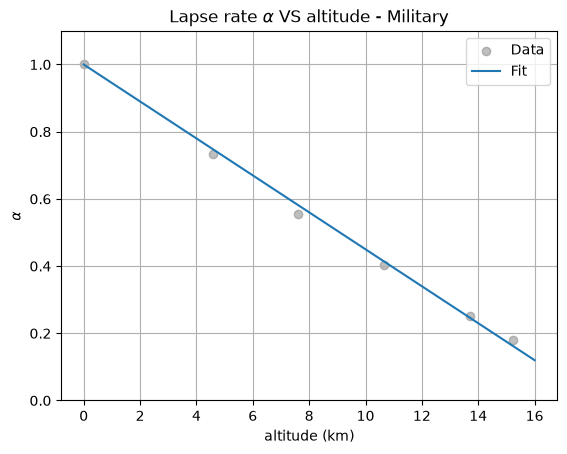

In [10]:
mil_altitude_data = ft2m(mil_data["altitude (ft)"])
mil_lapse_rate_data = mil_data["net thrust (lb)"] / mil_data["net thrust (lb)"].iloc[0]

mil_alpha_model = LinearRegression(fit_intercept=False)
mil_alpha_model.fit(
    mil_altitude_data.values.reshape(-1, 1),
    mil_lapse_rate_data.values.reshape(-1, 1) - 1,
)
altitude_predict = np.linspace(0.0, 16e3, 1000)
lapse_rate_predict = 1 + mil_alpha_model.predict(altitude_predict.reshape(-1, 1))

plt.scatter(
    mil_altitude_data / 1000,
    mil_lapse_rate_data,
    label="Data",
    color="gray",
    alpha=0.5,
)
plt.plot(altitude_predict / 1000, lapse_rate_predict, label="Fit")
plt.grid()
plt.xlabel("altitude (km)")
plt.ylabel(r"$\alpha$")
plt.title(r"Lapse rate $\alpha$ VS altitude - Military")
plt.ylim(0, 1.1)
plt.legend()
plt.savefig("alpha_model_mil.png")
plt.show()

In [11]:
print("slope for the military alpha model:", mil_alpha_model.coef_.squeeze(), "m-1")

slope for the military alpha model: -5.500232581938871e-05 m-1


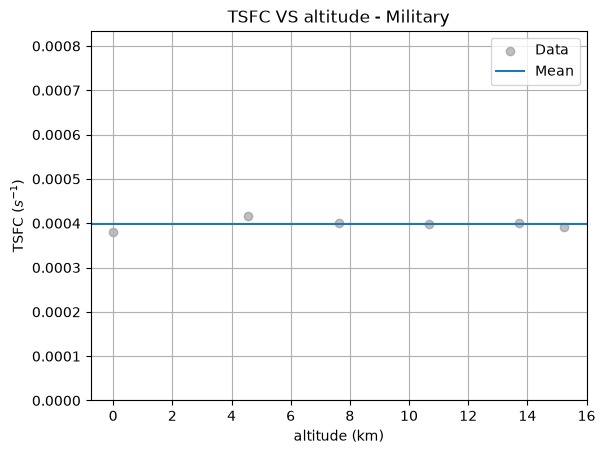

In [12]:
mil_altitude_data = ft2m(mil_data["altitude (ft)"])
mil_tsfc_data = mil_data["net tsfc (hr-1)"] / 3600
mil_avg_tsfc = mil_tsfc_data.mean()

plt.scatter(
    mil_altitude_data / 1000, mil_tsfc_data, color="gray", alpha=0.5, label="Data"
)
plt.axhline(mil_avg_tsfc, label="Mean")
plt.grid()
plt.xlabel("altitude (km)")
plt.ylabel(r"TSFC ($s^{-1}$)")
plt.title(r"TSFC VS altitude - Military")
plt.ylim(0, 2 * np.max(mil_tsfc_data))
plt.legend()
plt.savefig("tsfc_model_mil.png")
plt.show()

In [13]:
print("Military average TSFC:", mil_avg_tsfc, "s-1")

Military average TSFC: 0.00039842592592592593 s-1


## Wet

In [14]:
wet_raw_data_preselection = wet_raw_data
wet_data = wet_raw_data_preselection.groupby("altitude (ft)", as_index=False).mean()
wet_data

,altitude (ft),speed (kt),net thrust (lb),net tsfc (hr-1)
0,0.0,200.0,7210.000000,2.510667
1,15000.0,500.0,6118.333333,2.704667
2,25000.0,500.0,4938.333333,2.848000
3,35000.0,500.0,3661.666667,2.827667
4,45000.0,500.0,2220.000000,2.974667
5,50000.0,500.0,1708.333333,3.052000


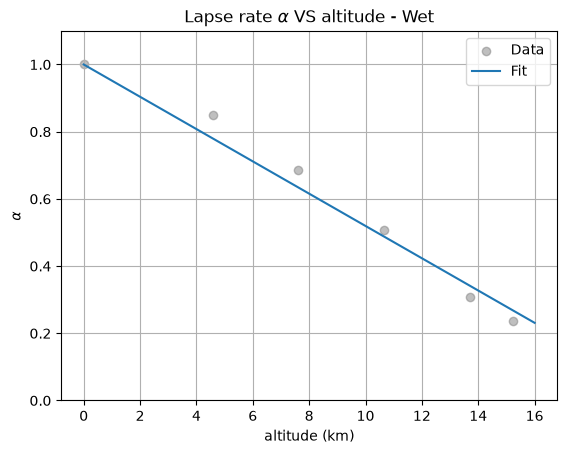

In [15]:
wet_altitude_data = ft2m(wet_data["altitude (ft)"])
wet_lapse_rate_data = wet_data["net thrust (lb)"] / wet_data["net thrust (lb)"].iloc[0]

wet_alpha_model = LinearRegression(fit_intercept=False)
wet_alpha_model.fit(
    wet_altitude_data.values.reshape(-1, 1),
    wet_lapse_rate_data.values.reshape(-1, 1) - 1,
)
altitude_predict = np.linspace(0.0, 16e3, 1000)
lapse_rate_predict = 1 + wet_alpha_model.predict(altitude_predict.reshape(-1, 1))

plt.scatter(
    wet_altitude_data / 1000,
    wet_lapse_rate_data,
    label="Data",
    color="gray",
    alpha=0.5,
)
plt.plot(altitude_predict / 1000, lapse_rate_predict, label="Fit")
plt.grid()
plt.xlabel("altitude (km)")
plt.ylabel(r"$\alpha$")
plt.title(r"Lapse rate $\alpha$ VS altitude - Wet")
plt.ylim(0, 1.1)
plt.legend()
plt.savefig("alpha_model_wet.png")
plt.show()

In [16]:
print("slope for the wet alpha model:", wet_alpha_model.coef_.squeeze(), "m-1")

slope for the wet alpha model: -4.805442917016957e-05 m-1


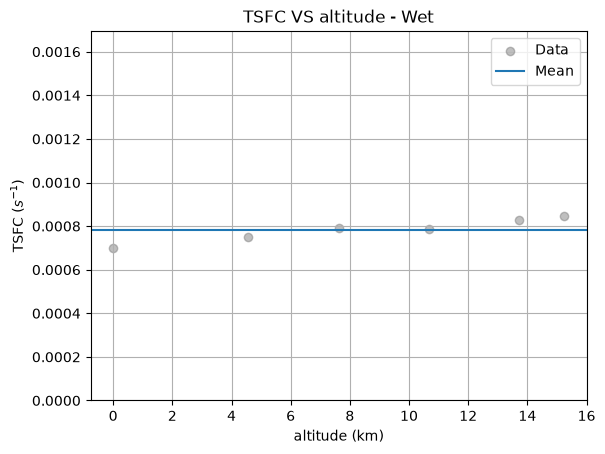

In [17]:
wet_altitude_data = ft2m(wet_data["altitude (ft)"])
wet_tsfc_data = wet_data["net tsfc (hr-1)"] / 3600
wet_avg_tsfc = wet_tsfc_data.mean()

plt.scatter(
    wet_altitude_data / 1000, wet_tsfc_data, color="gray", alpha=0.5, label="Data"
)
plt.axhline(wet_avg_tsfc, label="Mean")
plt.grid()
plt.xlabel("altitude (km)")
plt.ylabel(r"TSFC ($s^{-1}$)")
plt.title(r"TSFC VS altitude - Wet")
plt.ylim(0, 2 * np.max(wet_tsfc_data))
plt.legend()
plt.savefig("tsfc_model_wet.png")
plt.show()

In [18]:
print("Wet average TSFC:", wet_avg_tsfc, "s-1")

Wet average TSFC: 0.0007832253086419754 s-1
